# Employee Churn Dataset

In [1]:
# importing required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# reading csv file
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\Employee.csv")
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [3]:
# finding for null data
df.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [4]:
# finding some statistical info about data
df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [5]:
# printing information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [6]:
# printing shape of dataset
df.shape

(4653, 9)

In [7]:
# printing size of dataset
df.size

41877

In [8]:
# printing last 5 rows of dataset
df.tail()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0
4652,Bachelors,2015,Bangalore,3,33,Male,Yes,4,0


In [9]:
# finding duplicate value
df.duplicated().sum()

np.int64(1889)

In [10]:
# dropping duplicate rows
df.drop_duplicates(inplace = True)

In [11]:
df.duplicated().sum()

np.int64(0)

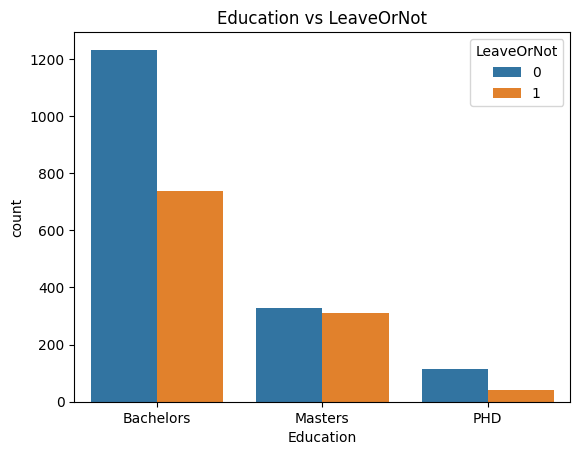

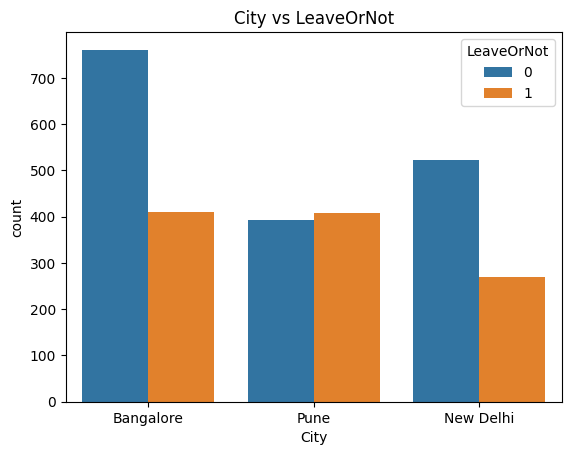

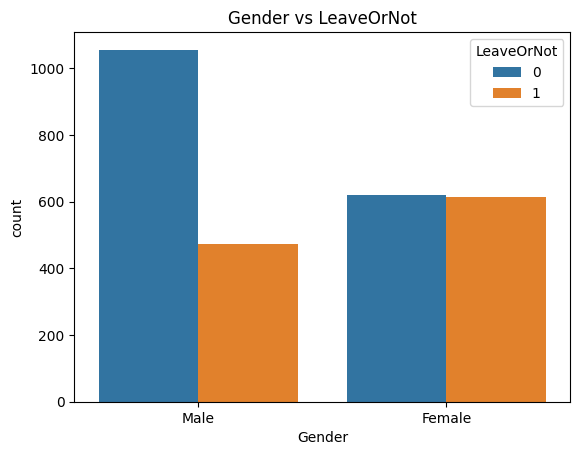

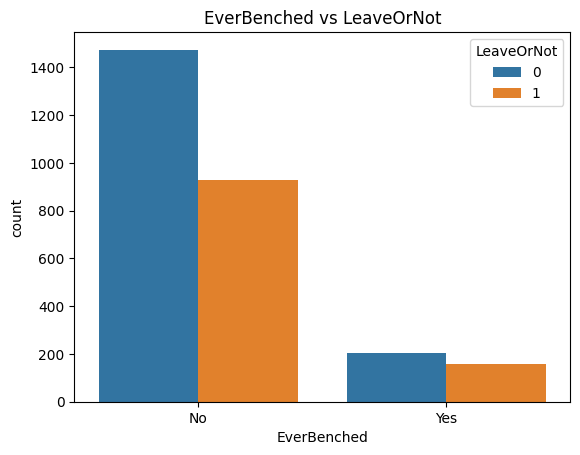

In [12]:
# plotting countplot to analyse trend between object type of columns with output
for i in df.select_dtypes(include = "object").columns:
    sns.countplot(x=i, hue='LeaveOrNot', data=df)
    plt.title(i+" "+"vs LeaveOrNot")
    plt.show()

In [13]:
# encoding of categorical data using get dummies method of pandas
df = pd.get_dummies(
    df,columns= ["EverBenched", "Gender"], drop_first=True,dtype="int64")

In [14]:
# encoding of categorical data using get map method
df["Education"] = df["Education"].map({"Bachelors" : 0, "Masters Education" : 1, "PHD" : 2})
df.head()

,Education,JoiningYear,City,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,EverBenched_Yes,Gender_Male
0,0.0,2017,Bangalore,3,34,0,0,0,1
1,0.0,2013,Pune,1,28,3,1,0,0
2,0.0,2014,New Delhi,3,38,2,0,0,0
3,NaN,2016,Bangalore,3,27,5,1,0,1
4,NaN,2017,Pune,3,24,2,1,1,1


In [15]:
# encoding of categorical data using get map method
df["City"] = df["City"].map({"Bangalore" : 0, "New Delhi" : 1, "Pune" : 2})
df.head()

,Education,JoiningYear,City,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,EverBenched_Yes,Gender_Male
0,0.0,2017,0,3,34,0,0,0,1
1,0.0,2013,2,1,28,3,1,0,0
2,0.0,2014,1,3,38,2,0,0,0
3,NaN,2016,0,3,27,5,1,0,1
4,NaN,2017,2,3,24,2,1,1,1


In [16]:
# finding unique values of column
df["LeaveOrNot"].unique()

array([0, 1])

In [17]:
# finding counts of values of columns
df["LeaveOrNot"].value_counts()

LeaveOrNot
0    1676
1    1088
Name: count, dtype: int64

In [18]:
# finding mean of float64 and int64 datatypes with respect to output data
for i in df.select_dtypes(include = ["int64", "float64"]).columns:
    if i not in df.select_dtypes(include = "object").columns:
        print(df.groupby('LeaveOrNot')[i].mean())

LeaveOrNot
0    0.172107
1    0.102696
Name: Education, dtype: float64
LeaveOrNot
0    2014.861575
1    2015.443015
Name: JoiningYear, dtype: float64
LeaveOrNot
0    0.780430
1    0.998162
Name: City, dtype: float64
LeaveOrNot
0    2.696301
1    2.543199
Name: PaymentTier, dtype: float64
LeaveOrNot
0    31.426014
1    30.224265
Name: Age, dtype: float64
LeaveOrNot
0    2.671838
1    2.602022
Name: ExperienceInCurrentDomain, dtype: float64
LeaveOrNot
0    0.0
1    1.0
Name: LeaveOrNot, dtype: float64
LeaveOrNot
0    0.120525
1    0.146140
Name: EverBenched_Yes, dtype: float64
LeaveOrNot
0    0.629475
1    0.435662
Name: Gender_Male, dtype: float64


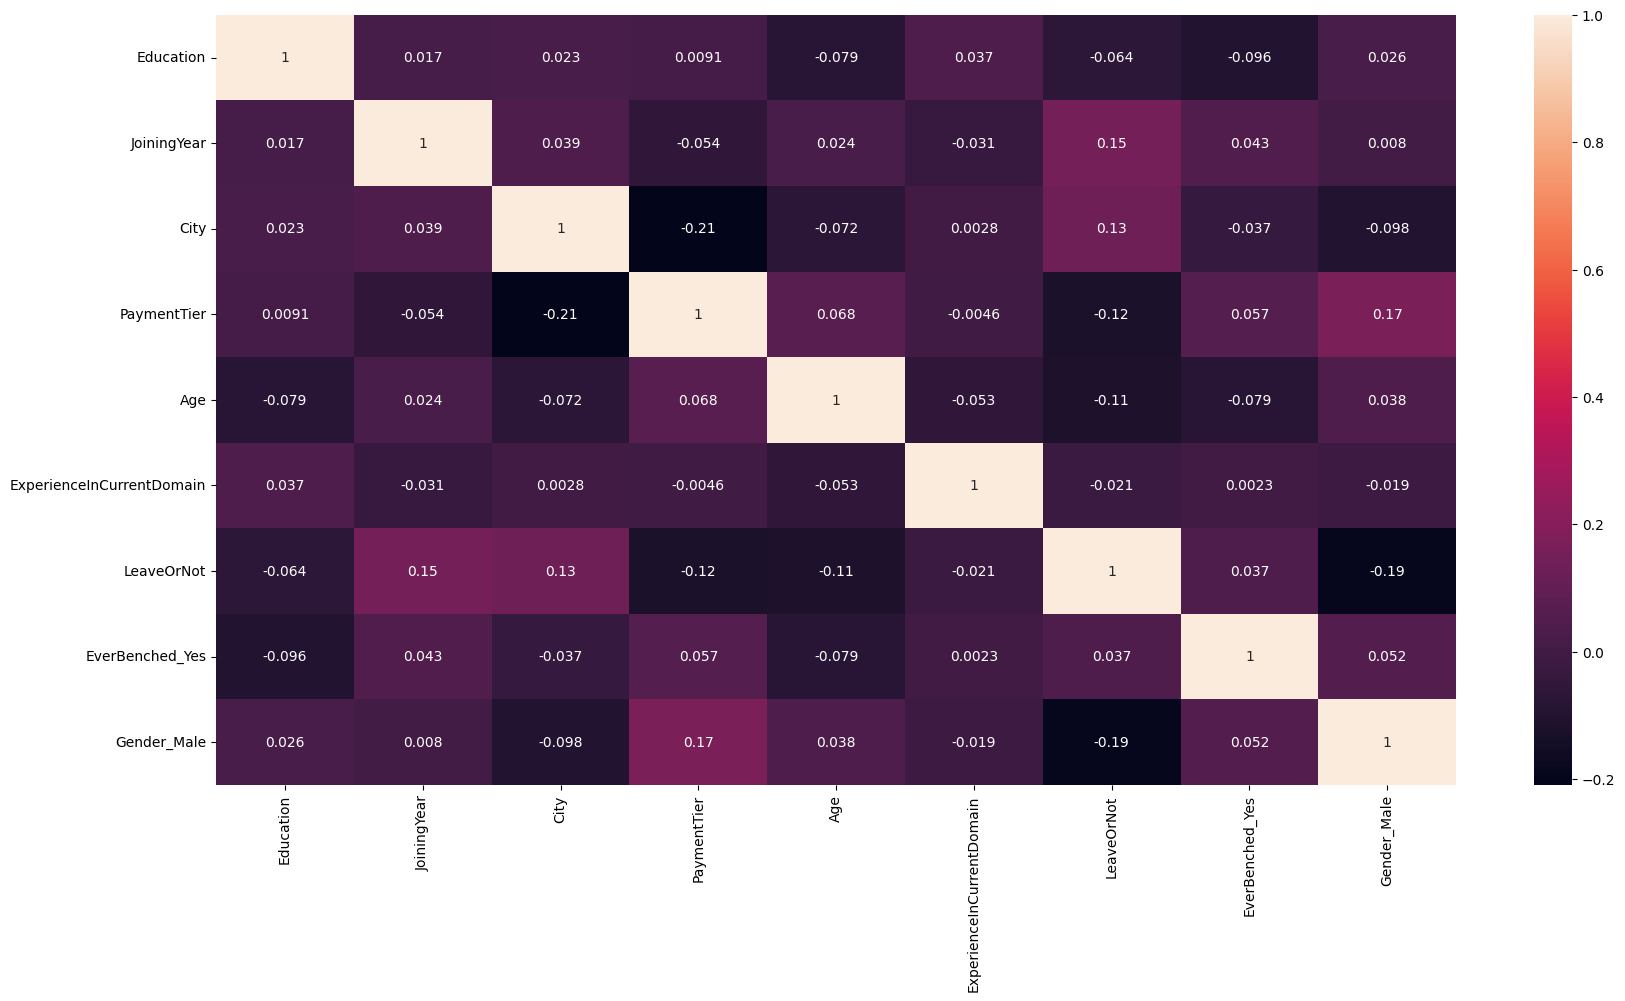

In [19]:
# plotting heatmap to analyse correlation between all numerical type of columns
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot = True)
plt.show()

In [20]:
df.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age',
       'ExperienceInCurrentDomain', 'LeaveOrNot', 'EverBenched_Yes',
       'Gender_Male'],
      dtype='object')

In [21]:
# dropping unnecessary columns
df.drop(columns = ["Education",  "EverBenched_Yes"], inplace = True)
df.head()

,JoiningYear,City,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,Gender_Male
0,2017,0,3,34,0,0,1
1,2013,2,1,28,3,1,0
2,2014,1,3,38,2,0,0
3,2016,0,3,27,5,1,1
4,2017,2,3,24,2,1,1


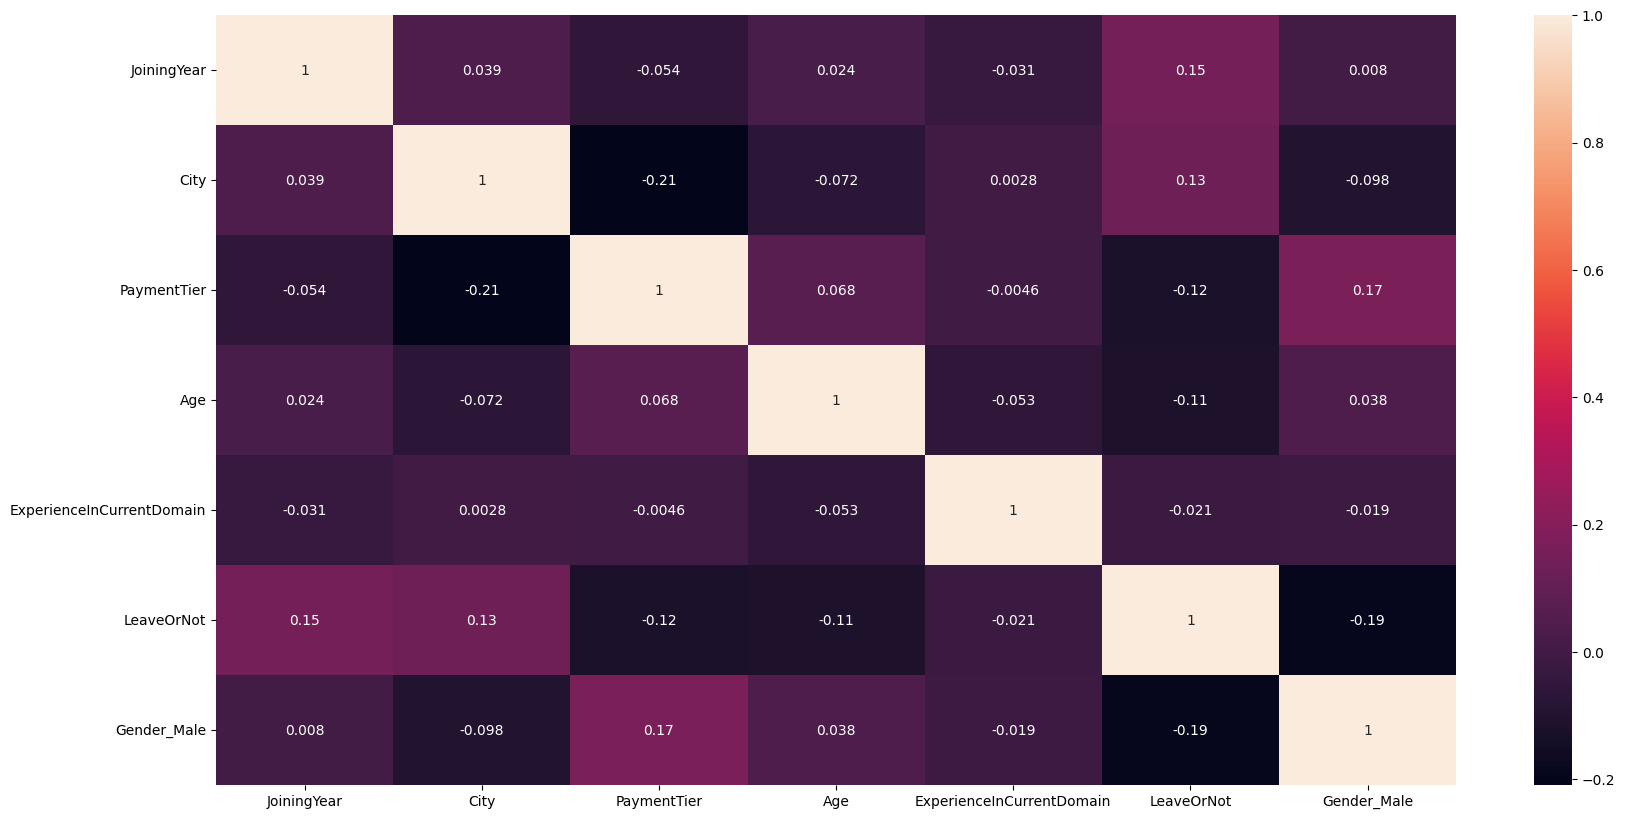

In [22]:
# plotting heatmap 
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot = True)
plt.show()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2764 entries, 0 to 4651
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   JoiningYear                2764 non-null   int64
 1   City                       2764 non-null   int64
 2   PaymentTier                2764 non-null   int64
 3   Age                        2764 non-null   int64
 4   ExperienceInCurrentDomain  2764 non-null   int64
 5   LeaveOrNot                 2764 non-null   int64
 6   Gender_Male                2764 non-null   int64
dtypes: int64(7)
memory usage: 172.8 KB


In [24]:
df.describe()

,JoiningYear,City,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,Gender_Male
count,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000
mean,2015.090449,0.866136,2.636035,30.952967,2.644356,0.393632,0.553184
std,1.885943,0.834141,0.624001,5.108872,1.610610,0.488643,0.497253
min,2012.000000,0.000000,1.000000,22.000000,0.000000,0.000000,0.000000
25%,2013.000000,0.000000,2.000000,27.000000,1.000000,0.000000,0.000000
50%,2015.000000,1.000000,3.000000,30.000000,2.000000,0.000000,1.000000
75%,2017.000000,2.000000,3.000000,35.000000,4.000000,1.000000,1.000000
max,2018.000000,2.000000,3.000000,41.000000,7.000000,1.000000,1.000000


In [25]:
df.columns

Index(['JoiningYear', 'City', 'PaymentTier', 'Age',
       'ExperienceInCurrentDomain', 'LeaveOrNot', 'Gender_Male'],
      dtype='object')

In [26]:
# splitting , training data
x = df[['JoiningYear', 'City', 'PaymentTier','Age',
       'ExperienceInCurrentDomain',  'Gender_Male']]
y = df['LeaveOrNot']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state= 50)

In [27]:
# standardization of testing and training data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [28]:
# applying logistic regression algorithm 
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=10)
lr.fit(x_train, y_train)

# printing score
print(lr.score(x_test, y_test)*100, lr.score(x_train, y_train)*100)

62.92947558770343 66.35006784260516


In [29]:
# finding accuracy score, confusion matrix analysis, classification report preparing
y_pred = lr.predict(x_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred)*100)

62.92947558770343


In [30]:
# printing confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[264,  57],
       [148,  84]])

In [31]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', max_depth=10,random_state=42)
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [32]:
# Prediction
y_pred = dt.predict(x_test)

In [33]:
# Accuracy score and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred)*100, confusion_matrix(y_test, y_pred)*100, classification_report(y_test, y_pred)*100)

73.77938517179024 [[27700  4400]
 [10100 13100]]               precision    recall  f1-score   support

           0       0.73      0.86      0.79       321
           1       0.75      0.56      0.64       232

    accuracy                           0.74       553
   macro avg       0.74      0.71      0.72       553
weighted avg       0.74      0.74      0.73       553
              precision    recall  f1-score   support

           0       0.73      0.86      0.79       321
           1       0.75      0.56      0.64       232

    accuracy                           0.74       553
   macro avg       0.74      0.71      0.72       553
weighted avg       0.74      0.74      0.73       553
              precision    recall  f1-score   support

           0       0.73      0.86      0.79       321
           1       0.75      0.56      0.64       232

    accuracy                           0.74       553
   macro avg       0.74      0.71      0.72       553
weighted avg       0.74    

In [34]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [35]:
# Prediction
y_pred = rf.predict(x_test)

In [36]:
# Accuracy score and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred)*100, confusion_matrix(y_test, y_pred)*100, classification_report(y_test, y_pred)*100)

75.04520795660035 [[28500  3600]
 [10200 13000]]               precision    recall  f1-score   support

           0       0.74      0.89      0.81       321
           1       0.78      0.56      0.65       232

    accuracy                           0.75       553
   macro avg       0.76      0.72      0.73       553
weighted avg       0.76      0.75      0.74       553
              precision    recall  f1-score   support

           0       0.74      0.89      0.81       321
           1       0.78      0.56      0.65       232

    accuracy                           0.75       553
   macro avg       0.76      0.72      0.73       553
weighted avg       0.76      0.75      0.74       553
              precision    recall  f1-score   support

           0       0.74      0.89      0.81       321
           1       0.78      0.56      0.65       232

    accuracy                           0.75       553
   macro avg       0.76      0.72      0.73       553
weighted avg       0.76    